# **Aprendizade Estadístico Automático**
## **Fundamentos Matemáticos del Aprendizaje Automático**

**Fecha**      : 21/04/2026

**Grupo No**  : 3

**Autores:**
- Sánchez Mendieta Juan Pablo
- Vásconez Pozo David Ruben
- Viteri Ayala Flavia Kamila

**Objetivo del notebook:**

Este notebook implementa el flujo completo de un proyecto de Machine Learning supervisado sobre 
el dataset **Wisconsin Breast Cancer Diagnostic (WBCD)**: preprocesamiento de datos, análisis 
exploratorio (EDA) y entrenamiento/evaluación de tres algoritmos de clasificación:

- Regresión Logística
- K-NN
- Naive Bayes

**Dataset:** Diagnostic Wisconsin Breast Cancer Database  
**Fuente:** UCI Machine Learning Repository / `sklearn.datasets`  
**Observaciones:** 569 mujeres · 30 características numéricas · 2 clases (Maligno=1, Benigno=0)  
**Distribución de clases:** 212 malignos · 357 benignos

---
# **Sección 0: Instalación y carga de librerías**

In [29]:
# ── Instalación de dependencias ───────────────────────────────────────────────
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

# ── Librerías estándar ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler, StandardScaler

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
# **Sección 1: Business Understanding**

In [ ]:
# ── Importación desde metadata UCI ─────────────────────────────────

meta = breast_cancer.metadata
info = meta.get('additional_info', {})

print('=' * 60)
print(f"  DATASET : {meta.get('name')}")
print(f"  UCI ID  : {meta.get('uci_id')}")
print('=' * 60)

print(f"\n📋 DESCRIPCIÓN GENERAL")
print(f"  {meta.get('abstract')}")

print(f"\n📊 CARACTERÍSTICAS")
print(f"  Área temática    : {meta.get('area')}")
print(f"  Tarea ML         : {meta.get('task')}")
print(f"  Tipo de datos    : {meta.get('characteristics')}")
print(f"  N° instancias    : {meta.get('num_instances')}")
print(f"  N° features      : {meta.get('num_features')}")
print(f"  Tipo de features : {meta.get('feature_types')}")
print(f"  Valores perdidos : {meta.get('has_missing_values')}")
print(f"  Año de creación  : {meta.get('year_of_dataset_creation')}")
print(f"  Columna target   : {meta.get('target_col')}")

print(f"\n👥 CREADORES")
for creator in meta.get('creators', []):
    print(f"  - {creator}")

print(f"\n📄 PAPER INTRODUCTORIO")
intro = meta.get('intro_paper', {})
print(f"  {intro.get('title', 'N/A')}")
print(f"  {intro.get('authors', 'N/A')} ({intro.get('year', '')})")

print(f"\n🔗 REPOSITORIO")
print(f"  {meta.get('repository_url')}")

print(f"\n📝 RESUMEN")
print(f"  {info.get('summary')}")

print(f"\n🎯 PROPÓSITO")
print(f"  {info.get('purpose')}")

print(f"\n🔬 LAS INSTANCIAS REPRESENTAN")
print(f"  {info.get('instances_represent')}")

print(f"\n⚙️  PREPROCESAMIENTO ORIGINAL")
print(f"  {info.get('preprocessing_description')}")

print(f"\n📐 DESCRIPCIÓN DE VARIABLES")
print(f"  {info.get('variable_info')}")

  DATASET : Breast Cancer Wisconsin (Diagnostic)
  UCI ID  : 17

📋 DESCRIPCIÓN GENERAL
  Diagnostic Wisconsin Breast Cancer Database.

📊 CARACTERÍSTICAS
  Área temática    : Health and Medicine
  Tarea ML         : None
  Tipo de datos    : ['Multivariate']
  N° instancias    : 569
  N° features      : 30
  Tipo de features : ['Real']
  Valores perdidos : no
  Año de creación  : 1993
  Columna target   : ['Diagnosis']

👥 CREADORES
  - William Wolberg
  - Olvi Mangasarian
  - Nick Street
  - W. Street

📄 PAPER INTRODUCTORIO
  Nuclear feature extraction for breast tumor diagnosis
  W. Street, W. Wolberg, O. Mangasarian (1993)

🔗 REPOSITORIO
  https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

📝 RESUMEN
  Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image. A few of the images can be found at http://www.cs.wisc.edu/~street/images/

Separating plane desc

In [53]:
# ── Diccionario de variables desde UCI ───────────────────────────────────────
breast_cancer.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no


In [56]:
# ── Diccionario de variables — construido desde paper original ────────────────

diccionario = {
    'ID':                   ('ID',      'Categórico',   'Sin unidad',  'Identificador único del paciente. No aporta valor predictivo.'),
    'Diagnosis':            ('Target',  'Categórico',   'Sin unidad',  'Diagnóstico: M = Maligno (1), B = Benigno (0).'),

    'radius':               ('Feature', 'Continuo',     'µm',          'Media de distancias del centro del núcleo a puntos del contorno.'),
    'texture':              ('Feature', 'Continuo',     'Adimensional','Desviación estándar de los valores de escala de grises del núcleo.'),
    'perimeter':            ('Feature', 'Continuo',     'µm',          'Longitud del contorno del núcleo celular.'),
    'area':                 ('Feature', 'Continuo',     'µm²',         'Superficie del núcleo celular.'),
    'smoothness':           ('Feature', 'Continuo',     'Adimensional','Variación local en las longitudes de los radios. 0 = perfectamente liso.'),
    'compactness':          ('Feature', 'Continuo',     'Adimensional','(perímetro² / área) − 1. Mide irregularidad de forma respecto a un círculo.'),
    'concavity':            ('Feature', 'Continuo',     'Adimensional','Severidad (profundidad) de las porciones cóncavas del contorno.'),
    'concave_points':       ('Feature', 'Continuo',     'Adimensional','Número de segmentos cóncavos en el contorno (normalizado).'),
    'symmetry':             ('Feature', 'Continuo',     'Adimensional','Diferencia entre ejes del núcleo. 0 = perfectamente simétrico.'),
    'fractal_dimension':    ('Feature', 'Continuo',     'Adimensional','Rugosidad del contorno: coastline approximation − 1.'),
}

sufijos = {
    '1': ('mean',  'Promedio de la característica en todas las células de la imagen'),
    '2': ('SE',    'Error estándar — variabilidad entre células de la misma muestra'),
    '3': ('worst', 'Valor más extremo registrado entre todas las células'),
}

# ── Construir DataFrame ───────────────────────────────────────────────────────
rows = []

# ID y Diagnosis
for nombre, (rol, tipo, unidad, desc) in list(diccionario.items())[:2]:
    rows.append({'Variable': nombre, 'Rol': rol, 'Tipo': tipo,
                 'Grupo': '—', 'Unidad': unidad, 'Descripción': desc})

# 30 features
for base, (rol, tipo, unidad, desc_base) in list(diccionario.items())[2:]:
    for sufijo, (grupo, desc_grupo) in sufijos.items():
        col = f'{base}{sufijo}'
        rows.append({
            'Variable':    col,
            'Rol':         rol,
            'Tipo':        tipo,
            'Grupo':       grupo,
            'Unidad':      unidad,
            'Descripción': f'{desc_base} — {desc_grupo}.'
        })

df_dict = pd.DataFrame(rows)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
df_dict

,Variable,Rol,Tipo,Grupo,Unidad,Descripción
0,ID,ID,Categórico,—,Sin unidad,Identificador único del paciente. No aporta valor predictivo.
1,Diagnosis,Target,Categórico,—,Sin unidad,"Diagnóstico: M = Maligno (1), B = Benigno (0)."
2,radius1,Feature,Continuo,mean,µm,Media de distancias del centro del núcleo a puntos del contorno. — Promedio de la característica en todas las células de la imagen.
3,radius2,Feature,Continuo,SE,µm,Media de distancias del centro del núcleo a puntos del contorno. — Error estándar — variabilidad entre células de la misma muestra.
4,radius3,Feature,Continuo,worst,µm,Media de distancias del centro del núcleo a puntos del contorno. — Valor más extremo registrado entre todas las células.
5,texture1,Feature,Continuo,mean,Adimensional,Desviación estándar de los valores de escala de grises del núcleo. — Promedio de la característica en todas las células de la imagen.
6,texture2,Feature,Continuo,SE,Adimensional,Desviación estándar de los valores de escala de grises del núcleo. — Error estándar — variabilidad entre células de la misma muestra.
7,texture3,Feature,Continuo,worst,Adimensional,Desviación estándar de los valores de escala de grises del núcleo. — Valor más extremo registrado entre todas las células.
8,perimeter1,Feature,Continuo,mean,µm,Longitud del contorno del núcleo celular. — Promedio de la característica en todas las células de la imagen.
9,perimeter2,Feature,Continuo,SE,µm,Longitud del contorno del núcleo celular. — Error estándar — variabilidad entre células de la misma muestra.


### **Análisis: Sección 1**

En esta sección se presenta una interpretación de las variables del dataset Wisconsin Breast Cancer Diagnostic (WBCD), el cual contiene 31 variables. De estas, una corresponde al identificador del paciente (ID), otra a la variable objetivo (Diagnosis), y las restantes 30 variables constituyen características numéricas continuas derivadas del análisis de imágenes de núcleos celulares obtenidas mediante aspiración con aguja fina (FNA) de masas mamarias.

En primer lugar, se encuentran variables asociadas al tamaño del núcleo celular, como radius, perimeter y area, las cuales suelen incrementarse en presencia de células malignas debido a procesos de crecimiento descontrolado. En segundo lugar, variables como texture aportan información sobre la heterogeneidad interna, reflejando la variabilidad en la intensidad de los píxeles, lo cual puede interpretarse como desorganización celular.

Por otra parte, características como smoothness, compactness, concavity y concave_points permiten evaluar la regularidad y complejidad del contorno nuclear. Estas variables son particularmente relevantes en el diagnóstico, ya que las células malignas tienden a presentar bordes más irregulares, con mayor presencia de invaginaciones y estructuras no uniformes. En este sentido, no solo el tamaño, sino también la forma del núcleo, se convierte en un indicador clave.

Finalmente, variables como symmetry y fractal_dimension capturan aspectos más avanzados de la organización geométrica y complejidad estructural del núcleo. La pérdida de simetría y el aumento en la rugosidad del contorno (dimensión fractal) son características frecuentemente asociadas con procesos malignos, aportando un nivel adicional de discriminación en los modelos predictivos.

---
# **Sección 2: Preprocesamiento de datos**

El preprocesamiento convierte los datos crudos en un formato adecuado para el modelado.  
En esta fase se realizan cuatro pasos fundamentales:

1. Carga del dataset desde `sklearn.datasets` y reconstrucción del DataFrame con columnas `id` y `diagnosis` (M/B) para simular el archivo CSV original del UCI.
2. Codificación de la variable objetivo: **M → 1** (maligno) y **B → 0** (benigno).
3. Descarte de la columna `id` (identificador sin poder predictivo).
4. Verificación de valores perdidos.

In [30]:
# ── 1. Instalar e importar ucimlrepo ─────────────────────────────────────────
import sys
!{sys.executable} -m pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

# ── 2. Cargar dataset desde UCI ───────────────────────────────────────────────
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features   # DataFrame 569×30
y = breast_cancer.data.targets    # DataFrame 569×1  (valores: 'M' / 'B')

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')
print(f'Valores únicos en y: {y["Diagnosis"].unique()}')

# Ver cómo lucen X e y antes de unirlos
display(X.head())
display(y.head())

Shape X : (569, 30)
Shape y : (569, 1)
Valores únicos en y: <StringArray>
['M', 'B']
Length: 2, dtype: str


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Diagnosis
0,M
1,M
2,M
3,M
4,M


In [31]:
# ── 3. Construir DataFrame unificado ─────────────────────────────────────────
df = X.copy()
df.insert(0, 'diagnosis', y['Diagnosis'].values)

print(f'Shape df: {df.shape}')
df.head(25)

Shape df: (569, 31)


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,M,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.71190,0.26540,0.4601,0.11890
1,M,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.24160,0.18600,0.2750,0.08902
2,M,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.45040,0.24300,0.3613,0.08758
3,M,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.68690,0.25750,0.6638,0.17300
4,M,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.40000,0.16250,0.2364,0.07678
5,M,12.450,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.53550,0.17410,0.3985,0.12440
6,M,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.37840,0.19320,0.3063,0.08368
7,M,13.710,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.26780,0.15560,0.3196,0.11510
8,M,13.000,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.53900,0.20600,0.4378,0.10720
9,M,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.10500,0.22100,0.4366,0.20750


In [32]:
# ── 4. Codificar: M → 1 (maligno), B → 0 (benigno) ─────────────────────────
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print('Distribución tras codificación:')
print(df['diagnosis'].value_counts().rename({1: 'Maligno (1)', 0: 'Benigno (0)'}))
df.head(25)

Distribución tras codificación:
diagnosis
Benigno (0)    357
Maligno (1)    212
Name: count, dtype: int64


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.71190,0.26540,0.4601,0.11890
1,1,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.24160,0.18600,0.2750,0.08902
2,1,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.45040,0.24300,0.3613,0.08758
3,1,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.68690,0.25750,0.6638,0.17300
4,1,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.40000,0.16250,0.2364,0.07678
5,1,12.450,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.53550,0.17410,0.3985,0.12440
6,1,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.37840,0.19320,0.3063,0.08368
7,1,13.710,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.26780,0.15560,0.3196,0.11510
8,1,13.000,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.53900,0.20600,0.4378,0.10720
9,1,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.10500,0.22100,0.4366,0.20750


In [33]:
# ── 5. Verificar valores perdidos ────────────────────────────────────────────
nulos = df.isnull().sum()
print('Valores perdidos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ Sin valores perdidos')
print(f'\nDataset final: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(25)

Valores perdidos por columna:
✅ Sin valores perdidos

Dataset final: 569 filas × 31 columnas


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.71190,0.26540,0.4601,0.11890
1,1,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.24160,0.18600,0.2750,0.08902
2,1,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.45040,0.24300,0.3613,0.08758
3,1,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.68690,0.25750,0.6638,0.17300
4,1,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.40000,0.16250,0.2364,0.07678
5,1,12.450,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.53550,0.17410,0.3985,0.12440
6,1,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.37840,0.19320,0.3063,0.08368
7,1,13.710,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.26780,0.15560,0.3196,0.11510
8,1,13.000,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.53900,0.20600,0.4378,0.10720
9,1,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.10500,0.22100,0.4366,0.20750


### **Análisis: Sección 2**

En esta sección se desarrolló el proceso de preprocesamiento de datos, etapa fundamental dentro de cualquier flujo de trabajo en Machine Learning, ya que condiciona directamente la calidad y validez de los resultados posteriores. Más que una fase meramente operativa, el preprocesamiento implica una serie de decisiones metodológicas orientadas a garantizar que los datos sean consistentes, interpretables y adecuados para ser utilizados por los algoritmos de aprendizaje.

El punto de partida consistió en la obtención del dataset a través de la librería ucimlrepo, lo cual permitió acceder de forma directa y reproducible al repositorio UCI. Esta elección asegura trazabilidad en la fuente de datos y reduce riesgos asociados a versiones inconsistentes o manipulaciones previas. En esta etapa, se realizó una separación inicial entre las variables explicativas (X) y la variable objetivo (y), manteniendo una estructura ordenada que facilitó el control del flujo de datos desde etapas tempranas.

Posteriormente, se procedió a la construcción de un DataFrame unificado, integrando las características y la variable objetivo en una sola estructura. Esta decisión responde a criterios de eficiencia analítica, ya que permite realizar operaciones exploratorias, transformaciones y validaciones de manera más directa. La ubicación de la variable diagnosis al inicio del DataFrame no solo mejora la legibilidad, sino que también refleja una organización lógica centrada en la variable de interés principal.

Uno de los pasos más relevantes en esta sección fue la codificación de la variable objetivo. Dado que diagnosis es una variable categórica con valores nominales ('M' y 'B'), se transforma en una variable binaria (1 y 0, respectivamente), lo cual es necesario para la mayoría de los algoritmos de clasificación. Más allá de ser una transformación técnica, esta codificación establece una representación numérica que permite modelar explícitamente la probabilidad de malignidad. Adicionalmente, se analizó la distribución de clases, identificándose una mayor proporción de casos benignos frente a malignos. Aunque existe un ligero desbalance, este no es lo suficientemente severo como para comprometer de forma crítica el entrenamiento de modelos, aunque sí sugiere la necesidad de considerar métricas de evaluación más robustas que la simple precisión.

Finalmente, se llevó a cabo una verificación de valores perdidos, confirmando que el dataset se encuentra completo. Este resultado representa una ventaja significativa, ya que elimina la necesidad de aplicar técnicas de imputación, las cuales pueden introducir sesgos o incertidumbre adicional en el análisis. La ausencia de datos faltantes permitió avanzar directamente hacia etapas de análisis exploratorio y modelado, con un mayor grado de confianza en la integridad de la información.

---
# **Sección 3: Análisis Exploratorio de Datos (EDA)**

El EDA permite entender la estructura, distribución y relaciones en los datos  
antes de entrenar cualquier modelo. Se analizan:

- Estadísticas descriptivas generales
- Distribución de la variable objetivo (balanceo de clases)
- Distribución de variables numéricas clave
- Análisis de correlación
- Detección de valores atípicos (boxplots)

In [ ]:
# ── 1. Estadísticas descriptivas ─────────────────────────────────────────────────
print('=== Estadísticas descriptivas (primeras 10 features) ===')
df.iloc[:, :11].describe().round(3)

=== Estadísticas descriptivas (primeras 10 features) ===


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,0.373,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063
std,0.484,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007
min,0.000,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050
25%,0.000,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058
50%,0.000,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062
75%,1.000,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066
max,1.000,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097


#### **Análisis: Estadísticas descriptivas**

En primer lugar, el conteo de observaciones (count) muestra un total de 569 registros en todas las variables analizadas, lo cual confirma nuevamente la ausencia de valores faltantes. Este resultado es consistente con lo observado en la etapa de preprocesamiento y refuerza la confiabilidad del dataset, al no requerir intervenciones adicionales como imputaciones o eliminación de registros.

En cuanto a la media (mean), se observa que la variable diagnosis presenta un valor aproximado de 0.373. Dado que esta variable está codificada como 1 para tumores malignos y 0 para benignos, este resultado indica que alrededor del 37.3% de los casos corresponden a diagnósticos malignos. Esta proporción confirma la existencia de un desbalance moderado en las clases, lo cual, aunque no es crítico, sí debe ser considerado en etapas posteriores, particularmente en la selección de métricas de evaluación.

Respecto a las variables predictoras, las medias permiten dimensionar el comportamiento típico de cada característica. Por ejemplo, variables como radius, perimeter y area presentan valores promedio relativamente altos, lo cual es coherente con su naturaleza física asociada al tamaño del núcleo celular. Estas métricas constituyen una primera aproximación a la escala de los datos y permiten anticipar posibles diferencias importantes entre variables.

La desviación estándar (std) aporta información sobre la dispersión de los datos alrededor de la media. En este sentido, se observa que variables como area presentan una variabilidad considerablemente mayor en comparación con otras como smoothness o fractal_dimension. Esta diferencia sugiere que ciertas características capturan fenómenos más heterogéneos dentro de la muestra, lo cual puede ser particularmente relevante para la discriminación entre clases. A su vez, evidencia la presencia de escalas distintas entre variables, un aspecto que deberá ser tratado en etapas posteriores mediante técnicas de normalización o estandarización.

Por otro lado, los valores mínimos y máximos (min y max) permiten identificar el rango de cada variable, ofreciendo una referencia clara sobre su amplitud. Esta información es útil tanto para detectar posibles valores atípicos como para comprender la magnitud de las diferencias entre observaciones. En complemento, los cuartiles (25%, 50%, 75%), y en particular la mediana, proporcionan una visión más robusta de la distribución de los datos, especialmente en presencia de asimetrías o valores extremos.

De manera integrada, este análisis descriptivo revela que las variables asociadas al tamaño del núcleo presentan una variabilidad significativa, lo cual sugiere un alto potencial discriminante en tareas de clasificación. En contraste, variables como smoothness o fractal_dimension operan en rangos más acotados, lo que evidencia diferencias importantes en escala y comportamiento. Esta heterogeneidad entre variables no solo es relevante desde el punto de vista interpretativo, sino que también tiene implicaciones directas en el modelado, reforzando la necesidad de aplicar transformaciones adecuadas en etapas posteriores del análisis.

En síntesis, esta subsección cumple un rol fundamental al proporcionar una comprensión inicial de la estructura y distribución de los datos, sentando las bases para decisiones metodológicas informadas en las siguientes fases del proceso de aprendizaje automático.

In [35]:
# ── Tipos de datos ────────────────────────────────────────────────────────────
print('Tipos de datos:')
print(df.dtypes.value_counts())
print(f'\nShape: {df.shape}')

Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64

Shape: (569, 31)


#### **Análisis: Tipos de datos**

El resumen de tipos de datos indica que el dataset está compuesto por 30 variables de tipo float64 y 1 variable de tipo int64. Esta distribución es consistente con la naturaleza del problema, ya que las variables predictoras corresponden a mediciones continuas derivadas de imágenes (por ejemplo, radio, área, textura), lo cual justifica su representación en formato decimal (float64). Por su parte, la única variable de tipo entero (int64) corresponde a la variable objetivo diagnosis, la cual ha sido previamente codificada en formato binario (0 para benigno y 1 para maligno).

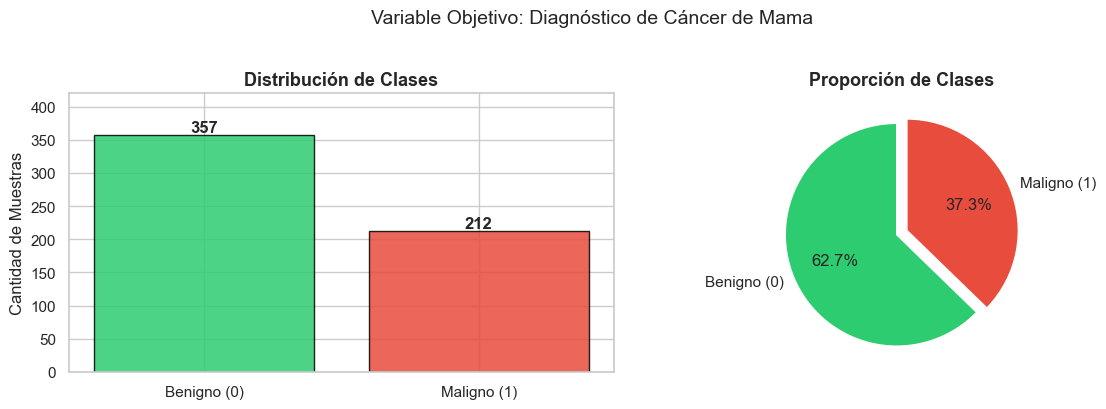

Benigno (0) : 357 muestras  (62.7%)
Maligno (1) : 212 muestras  (37.3%)


In [36]:
# ── Distribución de la variable objetivo ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
conteos = df['diagnosis'].value_counts().sort_index()
axes[0].bar(['Benigno (0)', 'Maligno (1)'], conteos.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Muestras')
axes[0].set_ylim(0, 420)

# Gráfico de torta
axes[1].pie(conteos.values, labels=['Benigno (0)', 'Maligno (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: Diagnóstico de Cáncer de Mama', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Benigno (0) : {conteos[0]} muestras  ({conteos[0]/len(df)*100:.1f}%)')
print(f'Maligno (1) : {conteos[1]} muestras  ({conteos[1]/len(df)*100:.1f}%)')

#### **Análisis: Distribución de la variable objetivo**

En esta subsección se analiza la distribución de la variable objetivo (diagnosis), lo cual constituye un paso fundamental para comprender la estructura del problema de clasificación antes de entrenar cualquier modelo. A través de una visualización combinada (un gráfico de barras y un gráfico de pastel) se examina tanto el número absoluto de observaciones por clase como su proporción relativa.

Los resultados muestran que el dataset contiene 357 casos benignos (62.7%) y 212 casos malignos (37.3%). Esta distribución evidencia un desbalance de clases moderado, en el cual la clase benigna predomina sobre la maligna. Desde una perspectiva analítica, este hallazgo es consistente con lo observado previamente en las estadísticas descriptivas, reforzando la validez de los resultados exploratorios iniciales.

El gráfico de barras permite identificar con claridad la diferencia en términos absolutos entre ambas clases, mostrando una mayor concentración de observaciones en la categoría benigna. Por su parte, el gráfico de torta facilita la interpretación proporcional, destacando visualmente que, aunque existe una diferencia, la clase minoritaria (maligna) mantiene una representación significativa dentro del dataset.

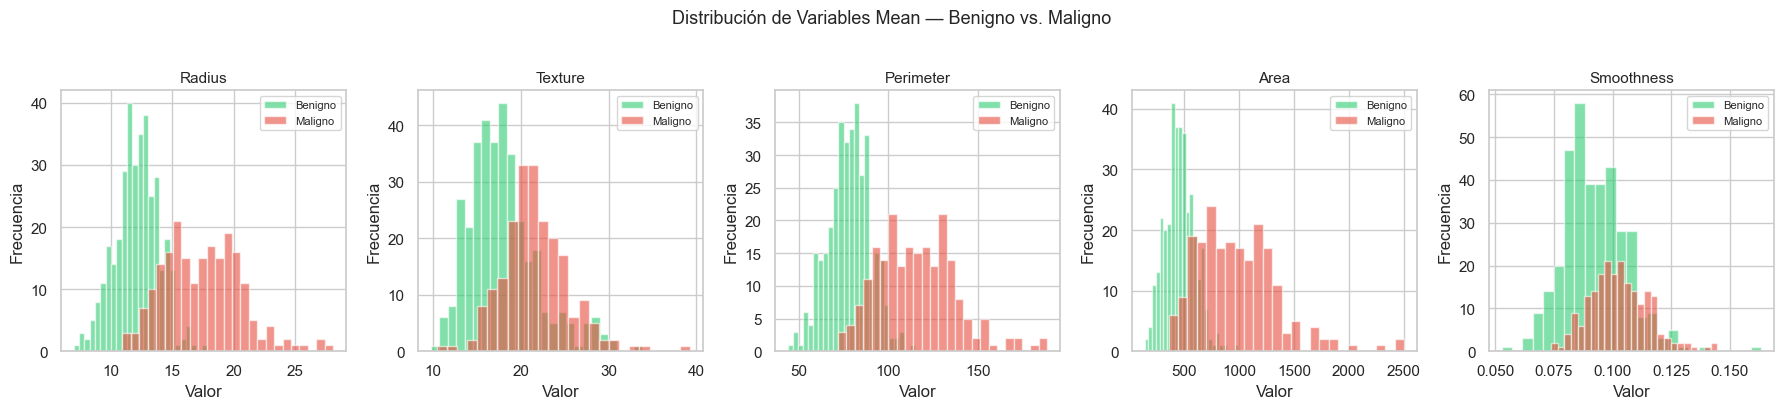

In [40]:
# ── Distribución de variables 'mean' (radio, textura, perímetro, área, suavidad) 
features_mean = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, features_mean):
    for label, color, name in [(0, '#2ecc71', 'Benigno'), (1, '#e74c3c', 'Maligno')]:
        ax.hist(df[df['diagnosis'] == label][feat].dropna(),
                bins=25, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(feat.replace('1', '').replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Mean — Benigno vs. Maligno', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### **Análisis: Distribución de variables mean**

En esta subsección se profundiza en el análisis exploratorio mediante la visualización de la distribución de las variables tipo _mean, específicamente radius1, texture1, perimeter1, area1 y smoothness1, diferenciando su comportamiento entre las clases benigna (0) y maligna (1). Este enfoque permite no solo entender la forma de las distribuciones, sino también evaluar visualmente el poder discriminante de cada variable.

En primer lugar, las variables asociadas al tamaño del núcleo celular (radius1, perimeter1 y area1) muestran un patrón claro y consistente: las distribuciones correspondientes a la clase maligna se encuentran desplazadas hacia valores más altos en comparación con la clase benigna. Este comportamiento es particularmente evidente en area1, donde los valores malignos presentan una mayor dispersión y alcanzan rangos considerablemente superiores. Esta separación entre distribuciones sugiere que estas variables poseen un alto potencial predictivo, ya que permiten distinguir de manera relativamente clara entre ambas clases.

En el caso de texture1, aunque también se observa una tendencia hacia valores más altos en la clase maligna, la superposición entre ambas distribuciones es mayor. Esto indica que, si bien la textura aporta información relevante, su capacidad discriminante es menor en comparación con las variables de tamaño. En términos prácticos, esto implica que esta variable podría ser más útil en combinación con otras, en lugar de ser utilizada de forma aislada.

Por otro lado, la variable smoothness1 presenta un comportamiento distinto. Sus distribuciones para ambas clases se encuentran altamente solapadas, con diferencias más sutiles en sus valores centrales y dispersión. Esto sugiere que la suavidad del contorno, al menos en su medida promedio, no constituye un predictor fuerte por sí mismo. Sin embargo, no debe descartarse su utilidad, ya que en modelos multivariados podría capturar interacciones relevantes con otras características.

Un aspecto importante que emerge de estas visualizaciones es la presencia de asimetrías y colas en las distribuciones, particularmente en variables como area1. Esto indica que los datos no siguen necesariamente una distribución normal, lo cual puede tener implicaciones en la selección de modelos o en la necesidad de aplicar transformaciones (como logaritmos) para mejorar la estabilidad de los algoritmos.

En conjunto, este análisis visual permite concluir que las variables de tamaño (radius, perimeter, area) destacan como las más relevantes para la clasificación, al presentar una clara diferenciación entre clases. En contraste, variables como texture y smoothness aportan información complementaria, aunque con menor capacidad discriminante individual. Este tipo de análisis no solo valida la pertinencia de las variables seleccionadas, sino que también orienta decisiones clave en la construcción de modelos, como la selección de características y la necesidad de transformaciones adicionales.

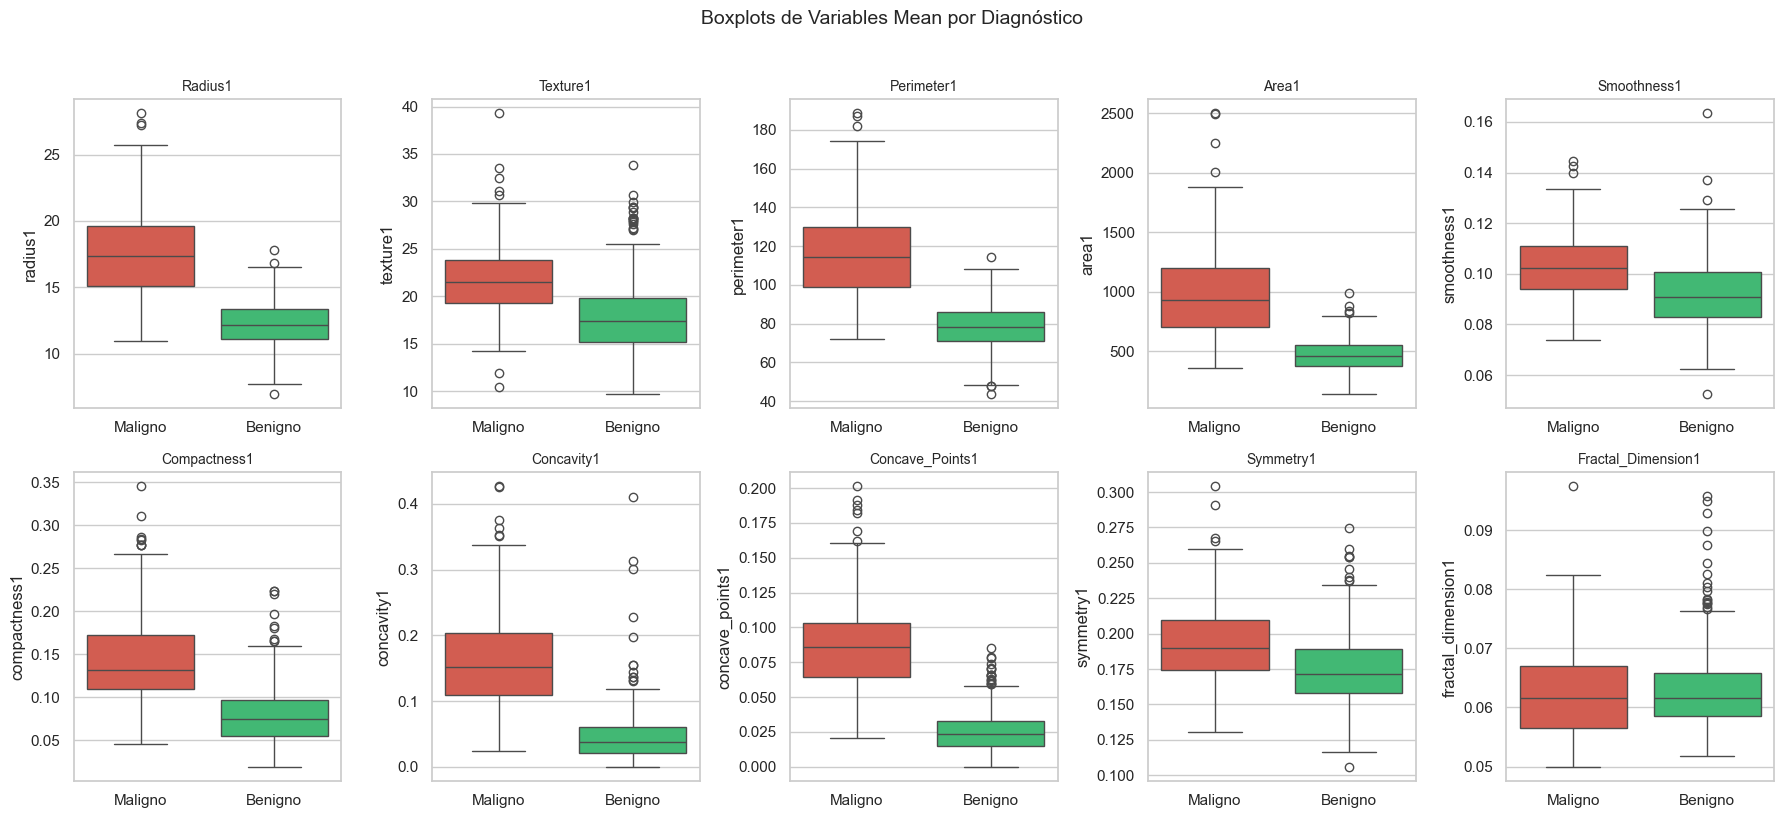

In [41]:
# ── Boxplots de variables 'mean' por diagnóstico ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
features_box = [c for c in df.columns if c.endswith('1') and c != 'diagnosis']

for ax, feat in zip(axes.flatten(), features_box):
    data_plot = df[['diagnosis', feat]].copy()
    data_plot['Diagnóstico'] = data_plot['diagnosis'].map({0: 'Benigno', 1: 'Maligno'})
    sns.boxplot(data=data_plot, x='Diagnóstico', y=feat, ax=ax,
                palette={'Benigno': '#2ecc71', 'Maligno': '#e74c3c'})
    ax.set_title(feat.replace('mean ', '').title(), fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Boxplots de Variables Mean por Diagnóstico', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### **Análisis: Valores atípicos por variables mean**

En esta subsección se profundiza el análisis exploratorio mediante el uso de boxplots para las variables tipo _mean, segmentadas según el diagnóstico (benigno vs. maligno). A diferencia de los histogramas, esta visualización permite evaluar de manera más precisa la posición central (mediana), la dispersión (rango intercuartílico) y la presencia de valores atípicos, facilitando una comparación directa entre clases.

En primer lugar, las variables relacionadas con el tamaño del núcleo (radius1, perimeter1, area1) muestran una separación clara entre las medianas de ambas clases. En todos los casos, la clase maligna presenta valores significativamente más altos que la benigna, lo cual es consistente con la evidencia clínica de que las células cancerosas tienden a tener núcleos más grandes. Además, se observa que la dispersión en la clase maligna es mayor, especialmente en area1, lo que sugiere una mayor heterogeneidad estructural en este tipo de células. Esta combinación de diferencia en medianas y mayor variabilidad refuerza el alto poder discriminante de estas variables.

En el caso de texture1, aunque la mediana de la clase maligna también es superior, la superposición entre los rangos intercuartílicos es más evidente, lo que indica una menor capacidad de separación en comparación con las variables de tamaño. Sin embargo, la presencia de valores atípicos en ambas clases sugiere que esta variable aún puede aportar información relevante en ciertos rangos específicos.

Las variables asociadas a la forma e irregularidad del contorno, como compactness1, concavity1 y concave_points1, presentan uno de los patrones más interesantes del análisis. En estos casos, la clase maligna no solo tiene medianas más altas, sino también una distribución claramente desplazada respecto a la clase benigna, con menor superposición entre cajas. Esto indica que estas variables son altamente efectivas para capturar diferencias estructurales entre células benignas y malignas, particularmente en términos de irregularidad del contorno.

Por otro lado, variables como smoothness1 y symmetry1 muestran diferencias más sutiles entre clases. Aunque las medianas de la clase maligna tienden a ser ligeramente superiores, existe una considerable superposición en los rangos intercuartílicos, lo que sugiere que su capacidad discriminante individual es limitada. No obstante, estas variables pueden ser relevantes en modelos multivariados donde interactúan con otras características.

Finalmente, la variable fractal_dimension1 presenta un comportamiento particular, con diferencias mínimas entre las medianas de ambas clases y una alta superposición. Esto indica que, en su forma promedio, esta variable podría tener un impacto menor en la clasificación, aunque no se descarta su utilidad en combinación con otras métricas más complejas.

Un aspecto transversal a todas las variables es la presencia de valores atípicos (outliers), especialmente en la clase maligna. Lejos de ser un problema, estos valores pueden representar casos clínicamente relevantes.

En conjunto, el análisis mediante boxplots confirma y refuerza los hallazgos previos: las variables relacionadas con el tamaño y la irregularidad del núcleo son las más relevantes para la discriminación entre clases, mientras que otras variables aportan información complementaria. Esta evidencia resulta clave para orientar decisiones posteriores como la selección de características, la reducción de dimensionalidad o la interpretación de modelos.

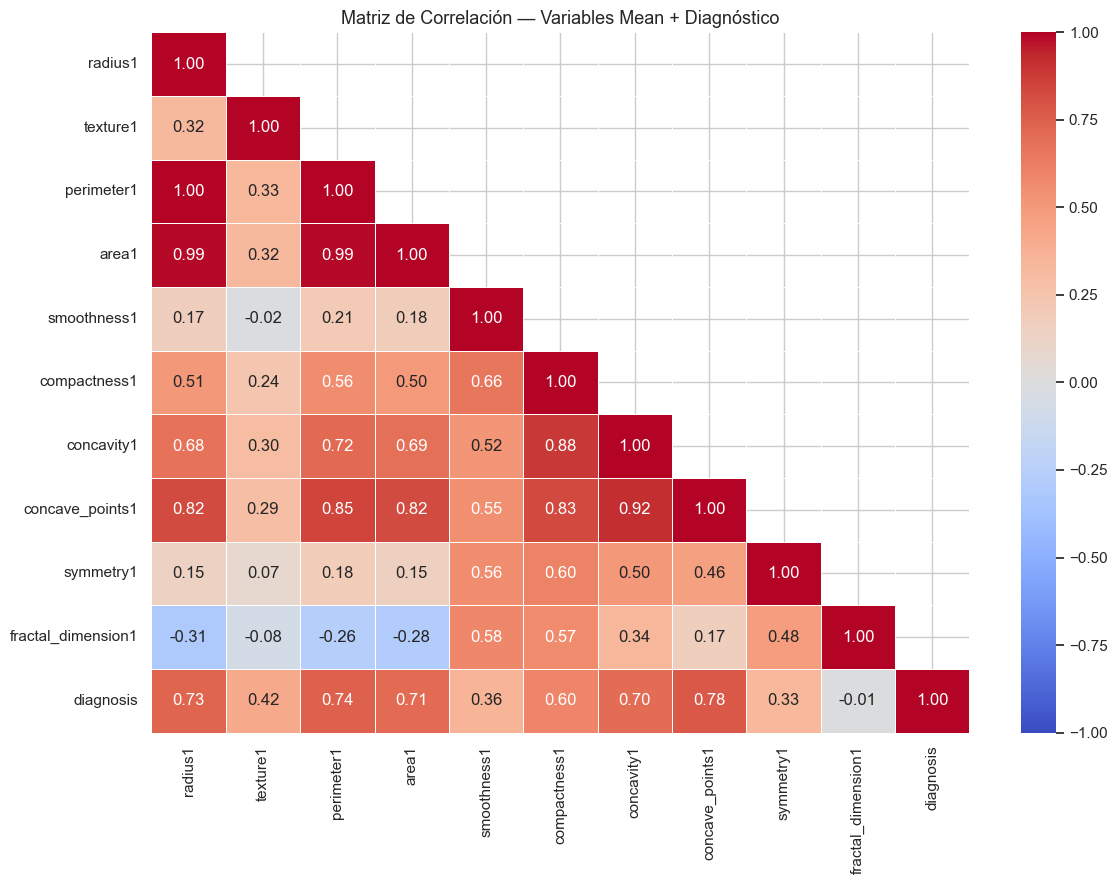

In [43]:
# ── Matriz de correlación (features 'mean') con la variable objetivo ──────────
features_corr = [c for c in df.columns if c.endswith('1')] + ['diagnosis']
corr_matrix   = df[features_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # oculta triángulo superior

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación — Variables Mean + Diagnóstico', fontsize=13)
plt.tight_layout()
plt.show()

#### **Análisis: Correlación entre variables**

En esta subsección se analiza la matriz de correlación entre las variables tipo _mean y la variable objetivo diagnosis, con el propósito de identificar relaciones lineales tanto entre las variables predictoras como entre estas y el resultado de clasificación. Este tipo de análisis es fundamental para comprender la estructura interna del dataset, así como para anticipar posibles problemas de multicolinealidad y evaluar el potencial predictivo de cada variable.

En primer lugar, al observar la relación entre las variables predictoras, se evidencia una alta correlación entre las variables de tamaño: radius1, perimeter1 y area1 presentan coeficientes cercanos a 1.00, lo cual indica una relación lineal casi perfecta. Este resultado es esperado, dado que estas variables derivan de la misma propiedad geométrica del núcleo celular. Sin embargo, desde una perspectiva de modelado, esto sugiere la presencia de multicolinealidad, lo que podría afectar a modelos sensibles a este fenómeno, como la regresión logística.

Por otro lado, también se observa una fuerte correlación entre variables relacionadas con la irregularidad del contorno, como concavity1 y concave_points1 (≈ 0.92), así como con compactness1. Estas relaciones indican que estas variables capturan aspectos similares de la morfología celular, particularmente en términos de complejidad y deformación del núcleo.

En cuanto a la relación con la variable objetivo diagnosis, se identifican varios patrones relevantes. Las variables con mayor correlación positiva son concave_points1 (0.78), perimeter1 (0.74), radius1 (0.73) y area1 (0.71), lo que confirma que tanto el tamaño como la irregularidad del núcleo son factores altamente asociados con la malignidad. Estas variables destacan como las más prometedoras desde el punto de vista predictivo.

Asimismo, variables como concavity1 (0.70) y compactness1 (0.60) también muestran correlaciones importantes, reforzando la idea de que la forma del contorno celular es un elemento clave en la diferenciación entre tumores benignos y malignos.

En contraste, variables como symmetry1 (0.33) y smoothness1 (0.36) presentan correlaciones más bajas, lo que sugiere una menor relación lineal con la variable objetivo. Más interesante aún es el caso de fractal_dimension1, cuya correlación es prácticamente nula (-0.01), indicando que esta variable, al menos en términos lineales, no aporta información significativa para la clasificación. Sin embargo, esto no descarta su posible utilidad en modelos no lineales o en combinación con otras variables.

Un aspecto adicional a destacar es que algunas variables presentan correlaciones negativas con otras características (por ejemplo, fractal_dimension1 con variables de tamaño), lo cual sugiere relaciones inversas en la morfología celular que podrían ser relevantes en análisis más avanzados.

En conjunto, esta matriz de correlación permite concluir que existe una estructura clara de dependencia entre variables, donde grupos de características capturan dimensiones similares del fenómeno biológico. Esto tiene implicaciones directas en el modelado, ya que sugiere la conveniencia de aplicar técnicas como PCA, regularización (L1/L2) o selección de variables, con el fin de reducir redundancias y mejorar la interpretabilidad del modelo.

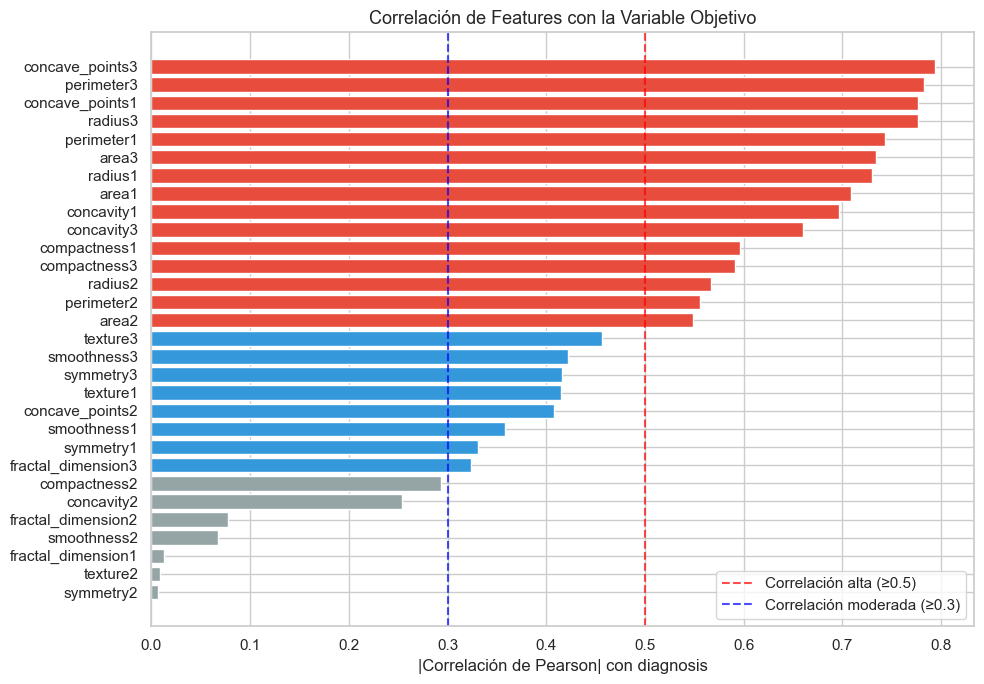

Top 10 features más correlacionadas con diagnosis:
concave_points3    0.794
perimeter3         0.783
concave_points1    0.777
radius3            0.776
perimeter1         0.743
area3              0.734
radius1            0.730
area1              0.709
concavity1         0.696
concavity3         0.660
Name: diagnosis, dtype: float64

Features con |corr| < 0.3 (candidatas a descartar): ['compactness2', 'concavity2', 'fractal_dimension2', 'smoothness2', 'fractal_dimension1', 'texture2', 'symmetry2']


In [44]:
# ── Correlación de todas las features con el target ───────────────────────────
corr_target = df.corr()['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v >= 0.5 else '#3498db' if v >= 0.3 else '#95a5a6'
          for v in corr_target.values]
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
plt.axvline(0.5, color='red',  linestyle='--', alpha=0.7, label='Correlación alta (≥0.5)')
plt.axvline(0.3, color='blue', linestyle='--', alpha=0.7, label='Correlación moderada (≥0.3)')
plt.xlabel('|Correlación de Pearson| con diagnosis')
plt.title('Correlación de Features con la Variable Objetivo', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 features más correlacionadas con diagnosis:')
print(corr_target.head(10).round(3))
print(f'\nFeatures con |corr| < 0.3 (candidatas a descartar): '
      f'{list(corr_target[corr_target < 0.3].index)}')

#### **Análisis: Correlación con la variable objetivo**

En esta subsección se profundiza el análisis mediante la evaluación de la correlación de todas las variables con la variable objetivo (diagnosis), utilizando el coeficiente de correlación de Pearson en valor absoluto. Este enfoque permite ordenar las variables según su grado de asociación lineal con el diagnóstico, facilitando la identificación de aquellas con mayor potencial predictivo y, al mismo tiempo, aquellas que podrían ser menos relevantes para el modelo.

Los resultados muestran de manera clara que las variables con mayor correlación corresponden principalmente a las mediciones tipo _worst y _mean asociadas al tamaño e irregularidad del núcleo celular. En particular, destacan variables como concave_points3 (≈ 0.794), perimeter3 (≈ 0.783), concave_points1 (≈ 0.777), radius3 (≈ 0.776) y perimeter1 (≈ 0.743). Este patrón es consistente con los análisis previos, donde se evidenció que tanto el tamaño como la complejidad del contorno son factores determinantes en la diferenciación entre tumores benignos y malignos.

Un hallazgo relevante es que las variables tipo _worst tienden a presentar correlaciones más altas que sus equivalentes _mean o _SE, lo cual sugiere que los valores extremos dentro de una muestra capturan mejor las anomalías celulares asociadas a la malignidad. Desde una perspectiva clínica, esto tiene sentido, ya que la presencia de células particularmente aberrantes puede ser más indicativa de un proceso maligno que el comportamiento promedio del conjunto celular.

Asimismo, variables como area, radius y perimeter, tanto en sus versiones promedio como extremas, mantienen correlaciones altas (superiores a 0.7 en varios casos), consolidándose como predictores robustos. De igual manera, variables relacionadas con la forma, como concavity y compactness, también presentan correlaciones importantes, reforzando la relevancia de la irregularidad del contorno nuclear.

Por otro lado, el análisis permite identificar un conjunto de variables con baja correlación (|corr| < 0.3), tales como compactness2, concavity2, fractal_dimension2, smoothness2, fractal_dimension1, texture2 y symmetry2. Estas variables, en principio, podrían considerarse candidatas a ser excluidas en un proceso de selección de características, ya que su contribución individual al modelo sería limitada en términos lineales. Sin embargo, es importante matizar que una baja correlación no implica necesariamente irrelevancia, especialmente en modelos no lineales o cuando existen interacciones entre variables.

Adicionalmente, la visualización incorpora umbrales de referencia para interpretar la magnitud de las correlaciones: valores superiores a 0.5 se consideran altos, mientras que aquellos por encima de 0.3 se interpretan como moderados. Esta clasificación facilita la toma de decisiones en términos de priorización de variables para el modelado.

En conjunto, este análisis confirma que existe una jerarquía clara en la relevancia de las variables, donde las características relacionadas con el tamaño y la irregularidad del núcleo (especialmente en sus valores extremos) dominan en términos de capacidad explicativa. Este hallazgo es clave para orientar estrategias de selección de variables, optimización de modelos y reducción de dimensionalidad, contribuyendo a construir modelos más eficientes, interpretables y alineados con la lógica del problema clínico.

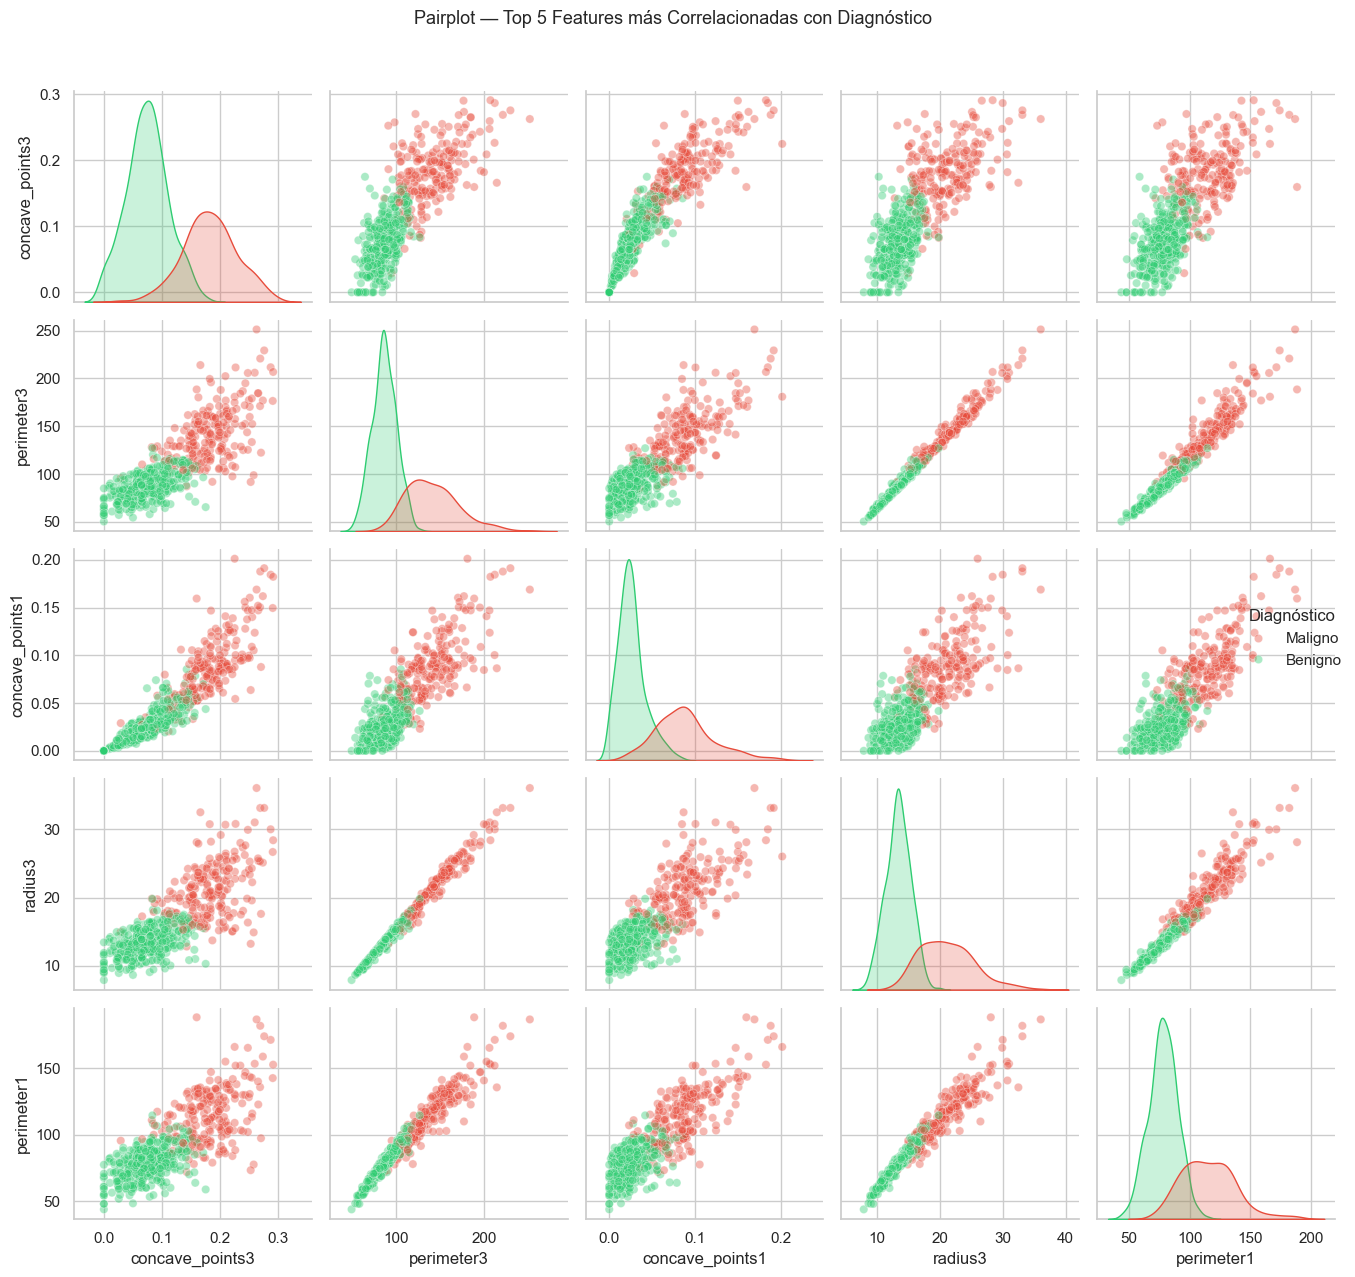

In [ ]:
# ── Pairplot de variables más relevantes ─────────────────────────────────────
top_features = corr_target.head(5).index.tolist()  # esta no cambia, se calcula sola
pair_df      = df[top_features + ['diagnosis']].copy()
pair_df['Diagnóstico'] = pair_df['diagnosis'].map({0: 'Benigno', 1: 'Maligno'})

g = sns.pairplot(pair_df.drop(columns='diagnosis'),
                 hue='Diagnóstico',
                 palette={'Benigno': '#2ecc71', 'Maligno': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairplot — Top 5 Features más Correlacionadas con Diagnóstico',
               y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#### **Análisis: Correlación entre pares de variables**

En esta subsección se presenta un análisis multivariado mediante un pairplot de las cinco variables más altamente correlacionadas con la variable objetivo (diagnosis). Esta visualización permite explorar simultáneamente la relación entre pares de variables y su capacidad conjunta para discriminar entre clases, proporcionando una visión más completa que los análisis univariados realizados previamente.

En primer lugar, los gráficos de dispersión fuera de la diagonal muestran patrones claramente diferenciados entre las clases benigna (verde) y maligna (rojo). Se observa que, en la mayoría de las combinaciones, los puntos correspondientes a tumores malignos tienden a concentrarse en regiones de valores más altos, mientras que los benignos se agrupan en rangos inferiores. Este patrón es consistente con los hallazgos previos, reforzando la idea de que variables como concave_points3, perimeter3, concave_points1, radius3 y perimeter1 tienen un alto poder discriminante, especialmente cuando se analizan en conjunto.

Un aspecto particularmente relevante es la presencia de relaciones lineales fuertes entre algunas variables, especialmente entre radius3, perimeter3 y perimeter1. Esto se evidencia en las nubes de puntos alineadas casi perfectamente en forma diagonal, lo cual confirma la alta correlación observada previamente en la matriz de correlación. Si bien esto refuerza la consistencia estructural del dataset, también vuelve a poner en evidencia la presencia de multicolinealidad, lo cual puede ser problemático para ciertos modelos y sugiere la conveniencia de aplicar técnicas de reducción de dimensionalidad o regularización.

En la diagonal del pairplot, las distribuciones (KDE) permiten observar con mayor claridad la separación entre clases para cada variable individual. En varios casos, como concave_points3 y radius3, se aprecia una separación parcial pero evidente entre las distribuciones, donde la clase maligna presenta una curva desplazada hacia la derecha. Esto indica que, aunque existe cierta superposición, hay regiones del espacio de características donde la probabilidad de pertenecer a una clase es significativamente mayor que a la otra.

Asimismo, la visualización conjunta permite identificar que la separación entre clases mejora cuando se consideran combinaciones de variables, incluso en casos donde la separación univariada no es completamente clara. Esto resalta la importancia de los modelos multivariados, capaces de capturar interacciones y patrones complejos que no son evidentes al analizar cada variable por separado.

Por otro lado, también se observa que, aunque existe una tendencia general de separación, hay zonas de superposición entre clases, lo que indica que el problema no es trivialmente separable de forma lineal perfecta. Esto sugiere que modelos más complejos o no lineales podrían capturar mejor estas fronteras de decisión.

En conjunto, el pairplot confirma que las variables seleccionadas no solo son relevantes de manera individual, sino que también presentan una estructura conjunta coherente y altamente informativa para la clasificación. Este análisis refuerza la validez de la selección de características realizada previamente y proporciona evidencia visual de que el dataset contiene patrones claros que pueden ser aprovechados por modelos de Machine Learning para distinguir entre tumores benignos y malignos de manera efectiva.

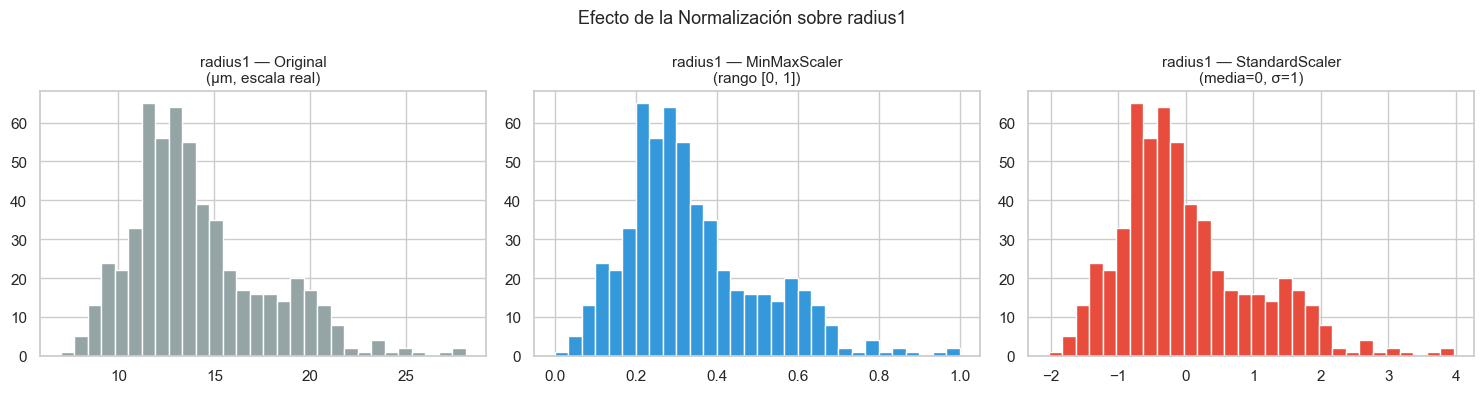

Rango (max-min) de las primeras 10 features:
radius1                 21.13
texture1                29.57
perimeter1             144.71
area1                 2357.50
smoothness1              0.11
compactness1             0.33
concavity1               0.43
concave_points1          0.20
symmetry1                0.20
fractal_dimension1       0.05

Feature con mayor rango : area3  (4068.8)
Feature con menor rango : fractal_dimension2  (0.0289)


In [71]:
# ── Normalización — comparación antes y después ───────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler

X_raw = df.drop(columns='diagnosis')

# MinMaxScaler → rango [0, 1], usado para K-NN
mm = MinMaxScaler()
X_mm = pd.DataFrame(mm.fit_transform(X_raw), columns=X_raw.columns)

# StandardScaler → media=0, desv.est=1, usado para RL
ss = StandardScaler()
X_ss = pd.DataFrame(ss.fit_transform(X_raw), columns=X_raw.columns)

# Comparar estadísticas de 'radius1' antes y después
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_raw['radius1'],  bins=30, color='#95a5a6', edgecolor='white')
axes[0].set_title('radius1 — Original\n(µm, escala real)',    fontsize=11)

axes[1].hist(X_mm['radius1'],   bins=30, color='#3498db', edgecolor='white')
axes[1].set_title('radius1 — MinMaxScaler\n(rango [0, 1])',   fontsize=11)

axes[2].hist(X_ss['radius1'],   bins=30, color='#e74c3c', edgecolor='white')
axes[2].set_title('radius1 — StandardScaler\n(media=0, σ=1)', fontsize=11)

plt.suptitle('Efecto de la Normalización sobre radius1', fontsize=13)
plt.tight_layout()
plt.show()

# Rango original de cada feature (muestra por qué es necesario normalizar)
rangos = X_raw.max() - X_raw.min()
print('Rango (max-min) de las primeras 10 features:')
print(rangos.head(10).round(2).to_string())
print(f'\nFeature con mayor rango : {rangos.idxmax()}  ({rangos.max():.1f})')
print(f'Feature con menor rango : {rangos.idxmin()}  ({rangos.min():.4f})')

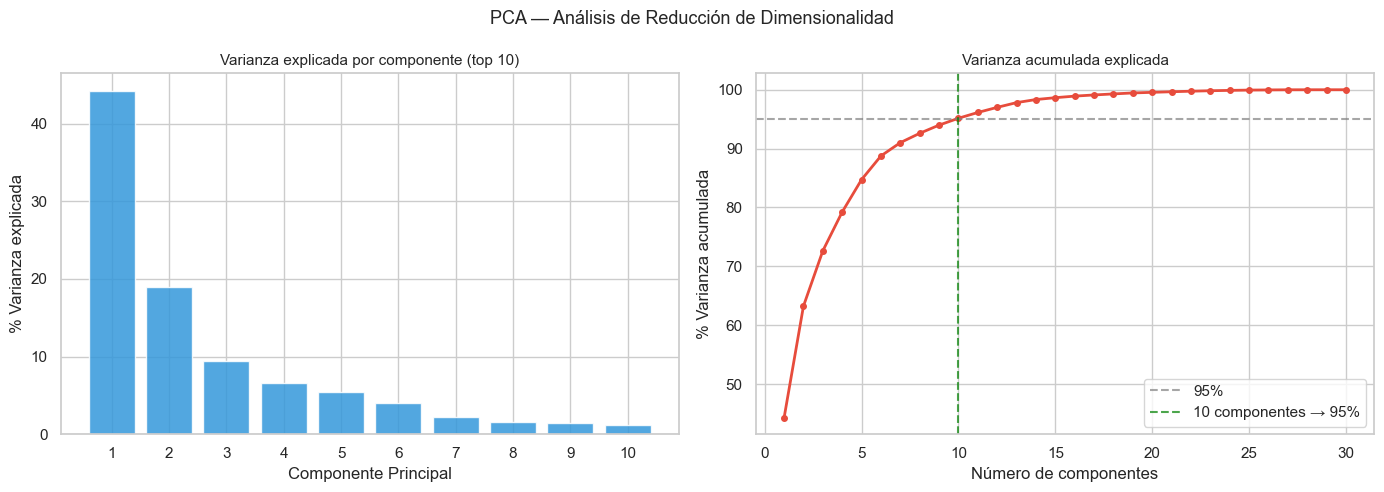

Varianza explicada por los primeros 2 componentes : 63.2%
Varianza explicada por los primeros 5 componentes : 84.7%
Componentes necesarios para explicar el 95%       : 10

→ Las 30 features originales pueden resumirse en 10 componentes
  sin perder casi información, confirmando la alta multicolinealidad del dataset.


In [72]:
# ── PCA — análisis de varianza explicada ─────────────────────────────────────
from sklearn.decomposition import PCA

# PCA requiere datos escalados
pca_full = PCA()
pca_full.fit(X_ss)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Cuántos componentes explican el 95%
n_95 = np.argmax(varianza_acumulada >= 95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
axes[0].bar(range(1, 11),
            pca_full.explained_variance_ratio_[:10] * 100,
            color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza explicada')
axes[0].set_title('Varianza explicada por componente (top 10)', fontsize=11)
axes[0].set_xticks(range(1, 11))

# Varianza acumulada
axes[1].plot(range(1, 31), varianza_acumulada, marker='o',
             color='#e74c3c', linewidth=2, markersize=4)
axes[1].axhline(95, color='gray', linestyle='--', alpha=0.7, label='95%')
axes[1].axvline(n_95, color='green', linestyle='--', alpha=0.7,
                label=f'{n_95} componentes → 95%')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('% Varianza acumulada')
axes[1].set_title('Varianza acumulada explicada', fontsize=11)
axes[1].legend()

plt.suptitle('PCA — Análisis de Reducción de Dimensionalidad', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Varianza explicada por los primeros 2 componentes : {varianza_acumulada[1]:.1f}%')
print(f'Varianza explicada por los primeros 5 componentes : {varianza_acumulada[4]:.1f}%')
print(f'Componentes necesarios para explicar el 95%       : {n_95}')
print(f'\n→ Las 30 features originales pueden resumirse en {n_95} componentes')
print(f'  sin perder casi información, confirmando la alta multicolinealidad del dataset.')

---
# **Sección 4: Modelo y evaluación**

Se implementan tres algoritmos de clasificación en dos versiones cada uno:
- **Baseline**: configuración por defecto / mínima, sin optimizar.
- **Mejorado**: ajuste de hiperparámetros, selección de features, cambio de escalado o eliminación de atípicos.

**Preparación común** para todos los modelos: división train/test (80/20), estratificada por clase.

In [57]:
# ── Función auxiliar: graficar métricas + curva ROC ───────────────────────────
def evaluar_modelo(nombre, y_test, y_pred, y_prob=None):
    """Imprime métricas completas y grafica la matriz de confusión + curva ROC."""
    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    spec = recall_score(y_test, y_pred, pos_label=0)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob if y_prob is not None else y_pred)

    print(f'\n{"─"*50}')
    print(f'  MODELO: {nombre}')
    print(f'{"─"*50}')
    print(classification_report(y_test, y_pred,
                                 target_names=['Benigno (0)', 'Maligno (1)']))
    print(f'  Exactitud   (Accuracy)   : {acc:.4f}')
    print(f'  Sensibilidad (Recall)    : {rec:.4f}')
    print(f'  Precisión   (Precision)  : {prec:.4f}')
    print(f'  Especificidad            : {spec:.4f}')
    print(f'  F1-Score                 : {f1:.4f}')
    print(f'  AUC-ROC                  : {auc:.4f}')

    # ── Gráficas ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Benigno', 'Maligno'],
                yticklabels=['Benigno', 'Maligno'])
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontsize=11)
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Curva ROC
    scores = y_prob if y_prob is not None else y_pred
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC = {auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC\n{nombre}', fontsize=11)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    return {'modelo': nombre, 'accuracy': acc, 'recall': rec,
            'precision': prec, 'specificity': spec, 'f1': f1, 'auc': auc}

print('✅ Función evaluar_modelo() definida')

✅ Función evaluar_modelo() definida


In [58]:
# ── Preparar conjuntos de datos ───────────────────────────────────────────────
X = df.drop(columns='diagnosis')
y = df['diagnosis']

# División 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Entrenamiento : {X_train.shape[0]} muestras')
print(f'Prueba        : {X_test.shape[0]} muestras')
print(f'\nDistribución en train — Benigno: {(y_train==0).sum()}  Maligno: {(y_train==1).sum()}')
print(f'Distribución en test  — Benigno: {(y_test==0).sum()}  Maligno: {(y_test==1).sum()}')

# Escalados disponibles
scaler_mm = MinMaxScaler(feature_range=(0, 1))
scaler_ss = StandardScaler()

X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

X_train_ss = scaler_ss.fit_transform(X_train)
X_test_ss  = scaler_ss.transform(X_test)

# Dataset reducido (solo features con |corr| >= 0.5)
features_altas = corr_target[corr_target >= 0.5].index.tolist()
X_train_red = scaler_ss.fit_transform(X_train[features_altas])
X_test_red  = scaler_ss.transform(X_test[features_altas])

print(f'\nFeatures seleccionadas (|corr|≥0.5): {len(features_altas)}')

resultados = []   # lista para tabla comparativa final

Entrenamiento : 455 muestras
Prueba        : 114 muestras

Distribución en train — Benigno: 285  Maligno: 170
Distribución en test  — Benigno: 72  Maligno: 42

Features seleccionadas (|corr|≥0.5): 15


---
## **4.1. Regresión Logística**
---

La Regresión Logística es un modelo lineal que estima la probabilidad de pertenencia a una clase  
usando la función sigmoide. Es eficiente, interpretable y funciona bien cuando las clases son linealmente separables.

**Baseline:** `StandardScaler` + parámetros por defecto  
**Mejorado:** `StandardScaler` + solo features con alta correlación + `C=0.1` (regularización más fuerte)


──────────────────────────────────────────────────
  MODELO: Regresión Logística — Baseline
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  Exactitud   (Accuracy)   : 0.9649
  Sensibilidad (Recall)    : 0.9286
  Precisión   (Precision)  : 0.9750
  Especificidad            : 0.9861
  F1-Score                 : 0.9512
  AUC-ROC                  : 0.9960


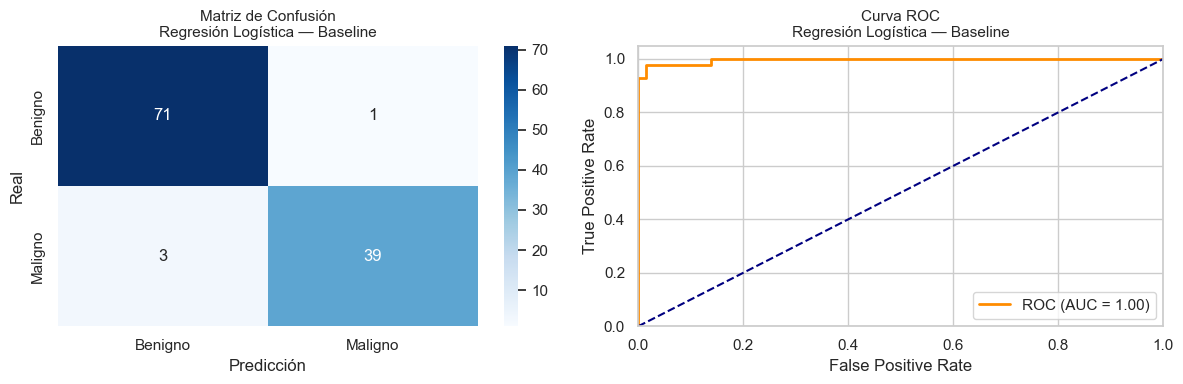

In [59]:
# ── Regresión Logística — Baseline ───────────────────────────────────────────
rl_base = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
rl_base.fit(X_train_ss, y_train)

y_pred_rl_base = rl_base.predict(X_test_ss)
y_prob_rl_base = rl_base.predict_proba(X_test_ss)[:, 1]

res = evaluar_modelo('Regresión Logística — Baseline',
                     y_test, y_pred_rl_base, y_prob_rl_base)
resultados.append(res)

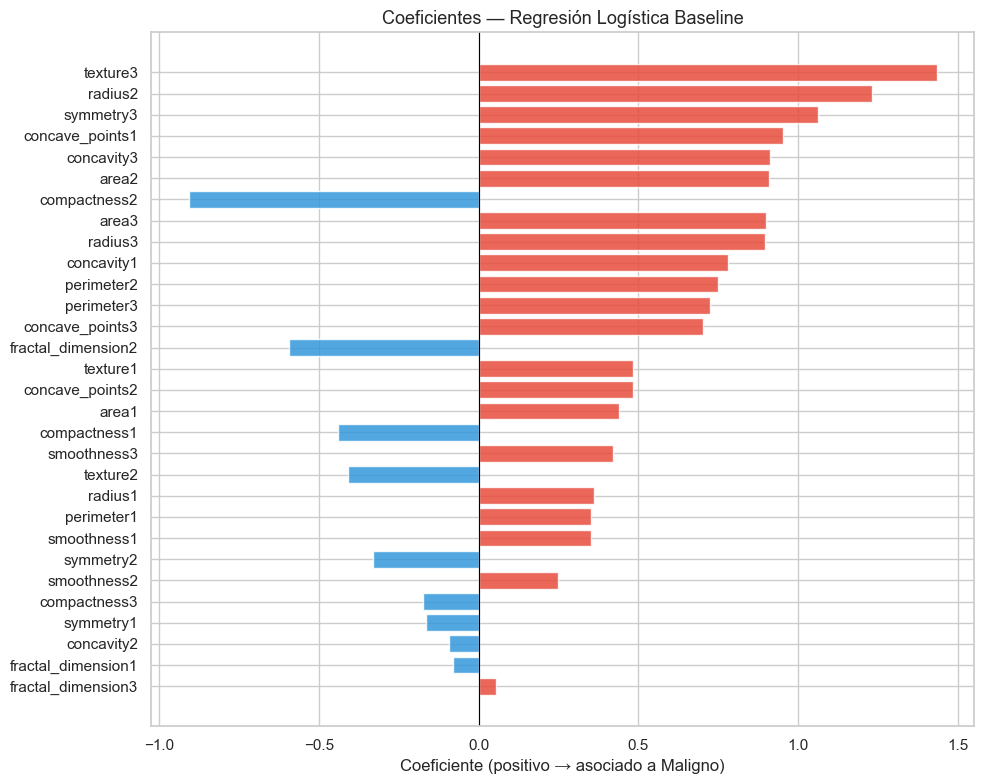

In [60]:
# ── Importancia de coeficientes (Baseline) ────────────────────────────────────
coef_df = pd.DataFrame({'feature': X.columns, 'coef': rl_base.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(10, 8))
colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors_coef, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regresión Logística Baseline', fontsize=13)
plt.xlabel('Coeficiente (positivo → asociado a Maligno)')
plt.tight_layout()
plt.show()


──────────────────────────────────────────────────
  MODELO: Regresión Logística — Mejorado (features reducidas + C=0.1)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.93      0.99      0.96        72
 Maligno (1)       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

  Exactitud   (Accuracy)   : 0.9474
  Sensibilidad (Recall)    : 0.8810
  Precisión   (Precision)  : 0.9737
  Especificidad            : 0.9861
  F1-Score                 : 0.9250
  AUC-ROC                  : 0.9977


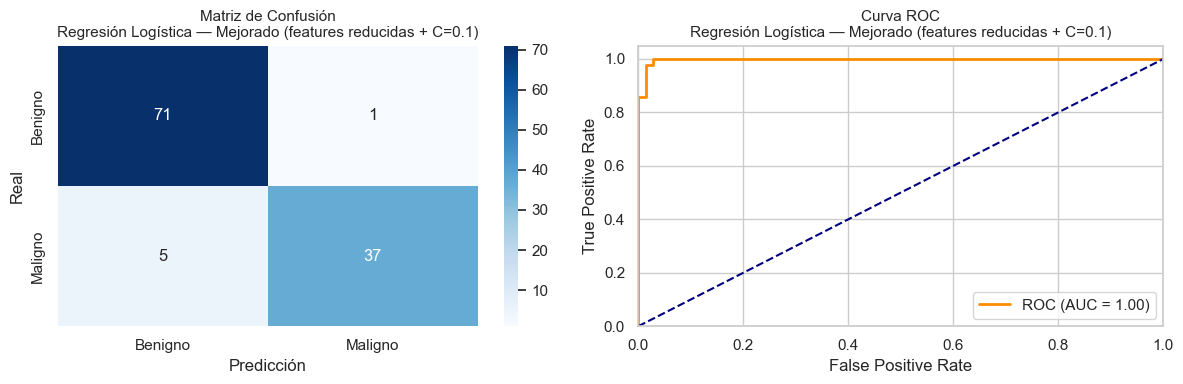

In [61]:
# ── Regresión Logística — Mejorado ───────────────────────────────────────────
# Cambios: features reducidas (alta correlación) + C=0.1 (mayor regularización)
rl_mejor = LogisticRegression(solver='lbfgs', max_iter=2000,
                               C=0.1, random_state=42)
rl_mejor.fit(X_train_red, y_train)

y_pred_rl_mejor = rl_mejor.predict(X_test_red)
y_prob_rl_mejor = rl_mejor.predict_proba(X_test_red)[:, 1]

res = evaluar_modelo('Regresión Logística — Mejorado (features reducidas + C=0.1)',
                     y_test, y_pred_rl_mejor, y_prob_rl_mejor)
resultados.append(res)

---
## **4.2. K-NN (K-Nearest Neighbors)**
---

K-NN clasifica una muestra según la clase mayoritaria de sus K vecinos más cercanos  
en el espacio de características. Es sensible a la escala, por lo que la normalización es obligatoria.

**Baseline:** `MinMaxScaler` + K=3, distancia euclídea, pesos uniformes  
**Mejorado:** `MinMaxScaler` + K=7, pesos por distancia + eliminación de atípicos


──────────────────────────────────────────────────
  MODELO: K-NN — Baseline (K=3, uniforme)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.95      0.99      0.97        72
 Maligno (1)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

  Exactitud   (Accuracy)   : 0.9561
  Sensibilidad (Recall)    : 0.9048
  Precisión   (Precision)  : 0.9744
  Especificidad            : 0.9861
  F1-Score                 : 0.9383
  AUC-ROC                  : 0.9846


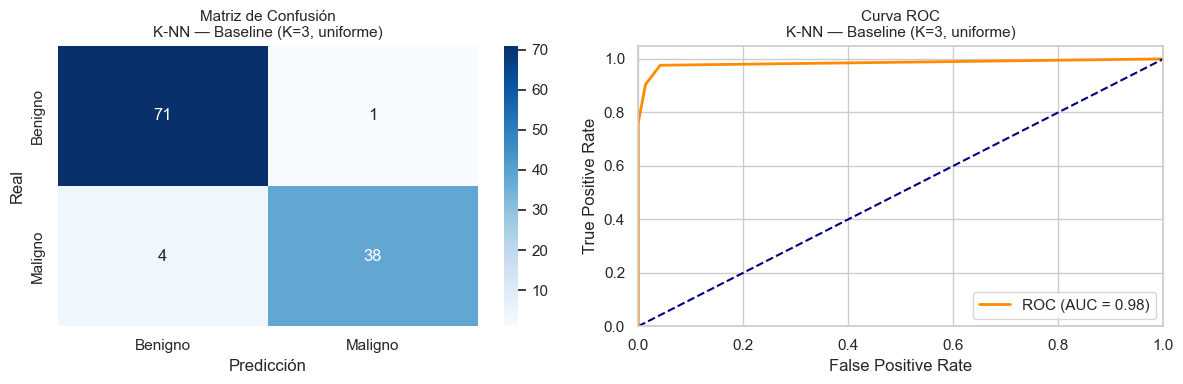

In [62]:
# ── K-NN — Baseline ───────────────────────────────────────────────────────────
knn_base = KNeighborsClassifier(n_neighbors=3, p=2, weights='uniform')
knn_base.fit(X_train_mm, y_train)

y_pred_knn_base = knn_base.predict(X_test_mm)
y_prob_knn_base = knn_base.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo('K-NN — Baseline (K=3, uniforme)',
                     y_test, y_pred_knn_base, y_prob_knn_base)
resultados.append(res)

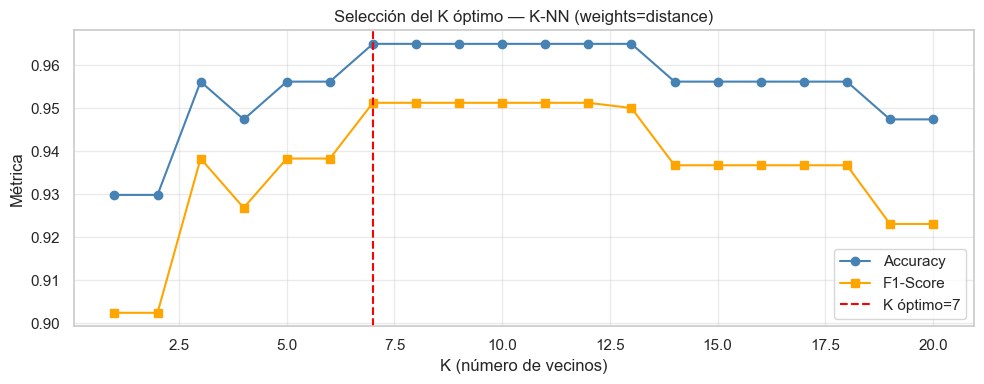

K óptimo según F1-Score: 7


In [63]:
# ── Buscar K óptimo ───────────────────────────────────────────────────────────
k_range  = range(1, 21)
acc_vals = []
f1_vals  = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, p=2, weights='distance')
    knn_k.fit(X_train_mm, y_train)
    y_p = knn_k.predict(X_test_mm)
    acc_vals.append(accuracy_score(y_test, y_p))
    f1_vals.append(f1_score(y_test, y_p))

k_opt = k_range[np.argmax(f1_vals)]

plt.figure(figsize=(10, 4))
plt.plot(k_range, acc_vals, marker='o', label='Accuracy',  color='steelblue')
plt.plot(k_range, f1_vals,  marker='s', label='F1-Score',  color='orange')
plt.axvline(k_opt, color='red', linestyle='--', label=f'K óptimo={k_opt}')
plt.xlabel('K (número de vecinos)')
plt.ylabel('Métrica')
plt.title('Selección del K óptimo — K-NN (weights=distance)')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f'K óptimo según F1-Score: {k_opt}')

Train tras limpieza de atípicos: 437 (18 removidos)

──────────────────────────────────────────────────
  MODELO: K-NN — Mejorado (K=7, distance, sin atípicos)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  Exactitud   (Accuracy)   : 0.9649
  Sensibilidad (Recall)    : 0.9286
  Precisión   (Precision)  : 0.9750
  Especificidad            : 0.9861
  F1-Score                 : 0.9512
  AUC-ROC                  : 0.9960


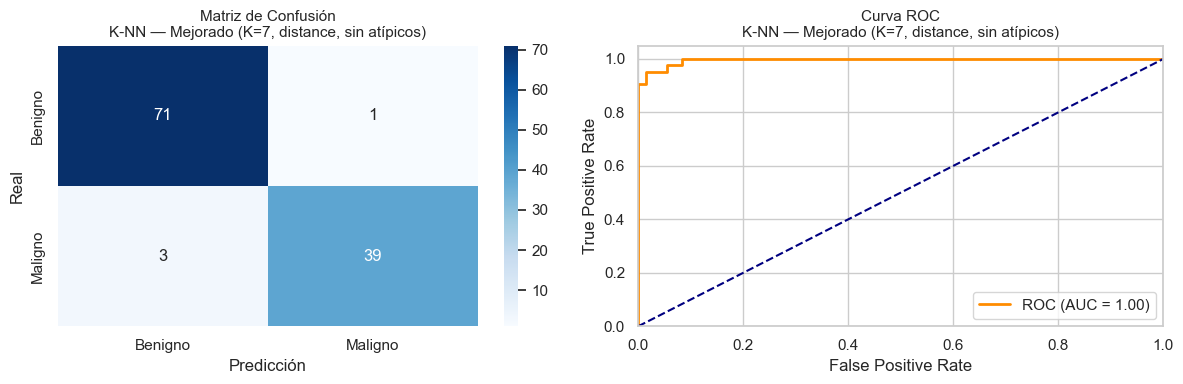

In [64]:
# ── K-NN — Mejorado ───────────────────────────────────────────────────────────
# Cambios: K=k_opt, pesos por distancia, entrenamiento sin atípicos extremos

# Eliminar atípicos en train con IQR (aplicado sobre datos normalizados)
X_train_mm_df = pd.DataFrame(X_train_mm, columns=X.columns)
y_train_arr   = y_train.reset_index(drop=True)

mask_out = pd.Series([True] * len(X_train_mm_df))
for col in features_altas[:5]:   # aplicar solo en top 5 features
    Q1c = X_train_mm_df[col].quantile(0.25)
    Q3c = X_train_mm_df[col].quantile(0.75)
    IQRc = Q3c - Q1c
    mask_out &= (X_train_mm_df[col] >= Q1c - 1.5*IQRc) & \
                (X_train_mm_df[col] <= Q3c + 1.5*IQRc)

X_train_clean = X_train_mm_df[mask_out].values
y_train_clean = y_train_arr[mask_out].values
print(f'Train tras limpieza de atípicos: {len(X_train_clean)} ({len(X_train_mm_df)-len(X_train_clean)} removidos)')

knn_mejor = KNeighborsClassifier(n_neighbors=k_opt, p=2, weights='distance')
knn_mejor.fit(X_train_clean, y_train_clean)

y_pred_knn_mejor = knn_mejor.predict(X_test_mm)
y_prob_knn_mejor = knn_mejor.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo(f'K-NN — Mejorado (K={k_opt}, distance, sin atípicos)',
                     y_test, y_pred_knn_mejor, y_prob_knn_mejor)
resultados.append(res)

---
## **4.3. Naive Bayes (Gaussiano)**
---

Naive Bayes asume independencia condicional entre features dada la clase,  
y modela cada feature con una distribución gaussiana. Es rápido, robusto a datos de alta dimensión  
y funciona sorprendentemente bien incluso cuando la asunción de independencia no se cumple perfectamente.

**Baseline:** GaussianNB con `var_smoothing=1e-9` (por defecto), sin escalar (NB no requiere escala)  
**Mejorado:** `var_smoothing` ajustado + features reducidas


──────────────────────────────────────────────────
  MODELO: Naive Bayes — Baseline (var_smoothing=1e-9)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.91      1.00      0.95        72
 Maligno (1)       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

  Exactitud   (Accuracy)   : 0.9386
  Sensibilidad (Recall)    : 0.8333
  Precisión   (Precision)  : 1.0000
  Especificidad            : 1.0000
  F1-Score                 : 0.9091
  AUC-ROC                  : 0.9934


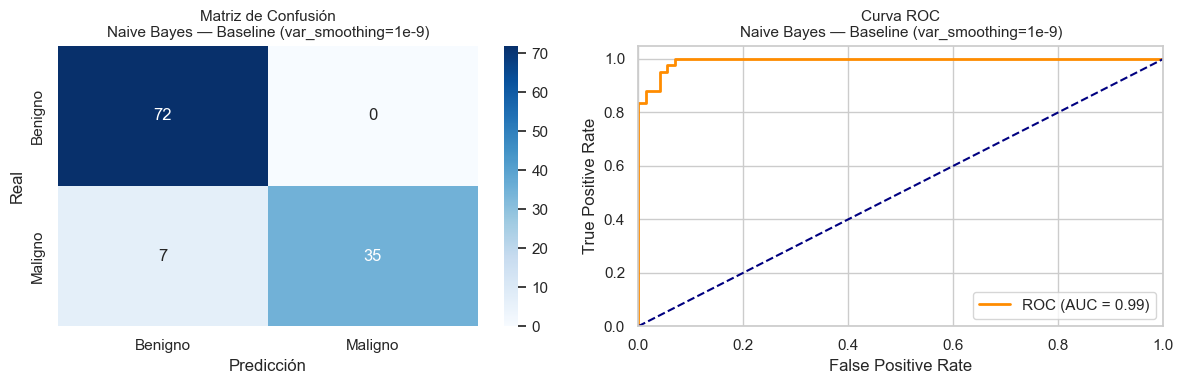

In [65]:
# ── Naive Bayes — Baseline ────────────────────────────────────────────────────
# NB no necesita normalización (trabaja con distribuciones)
X_train_np = X_train.values
X_test_np  = X_test.values

nb_base = GaussianNB()
nb_base.fit(X_train_np, y_train)

y_pred_nb_base = nb_base.predict(X_test_np)
y_prob_nb_base = nb_base.predict_proba(X_test_np)[:, 1]

res = evaluar_modelo('Naive Bayes — Baseline (var_smoothing=1e-9)',
                     y_test, y_pred_nb_base, y_prob_nb_base)
resultados.append(res)

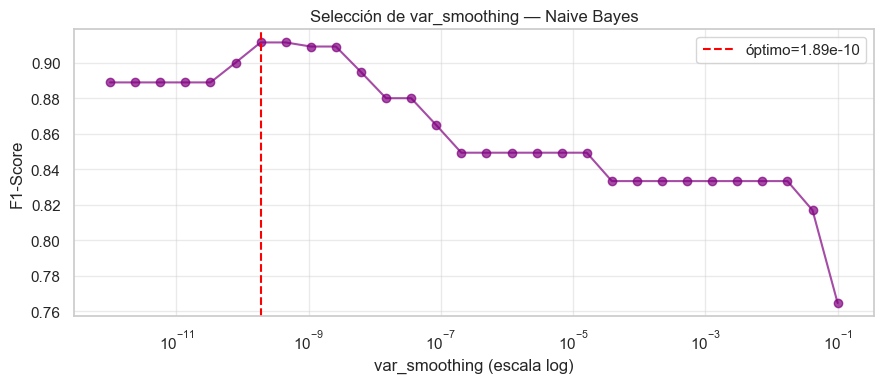

var_smoothing óptimo: 1.8874e-10


In [66]:
# ── Buscar var_smoothing óptimo ───────────────────────────────────────────────
smoothing_vals = np.logspace(-12, -1, 30)
f1_smooth = []

for sv in smoothing_vals:
    nb_s = GaussianNB(var_smoothing=sv)
    nb_s.fit(X_train_np, y_train)
    f1_smooth.append(f1_score(y_test, nb_s.predict(X_test_np)))

sv_opt = smoothing_vals[np.argmax(f1_smooth)]

plt.figure(figsize=(9, 4))
plt.semilogx(smoothing_vals, f1_smooth, marker='o', color='purple', alpha=0.7)
plt.axvline(sv_opt, color='red', linestyle='--', label=f'óptimo={sv_opt:.2e}')
plt.xlabel('var_smoothing (escala log)')
plt.ylabel('F1-Score')
plt.title('Selección de var_smoothing — Naive Bayes')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f'var_smoothing óptimo: {sv_opt:.4e}')


──────────────────────────────────────────────────
  MODELO: Naive Bayes — Mejorado (var_smoothing=1.89e-10, features reducidas)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.92      0.99      0.95        72
 Maligno (1)       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

  Exactitud   (Accuracy)   : 0.9386
  Sensibilidad (Recall)    : 0.8571
  Precisión   (Precision)  : 0.9730
  Especificidad            : 0.9861
  F1-Score                 : 0.9114
  AUC-ROC                  : 0.9921


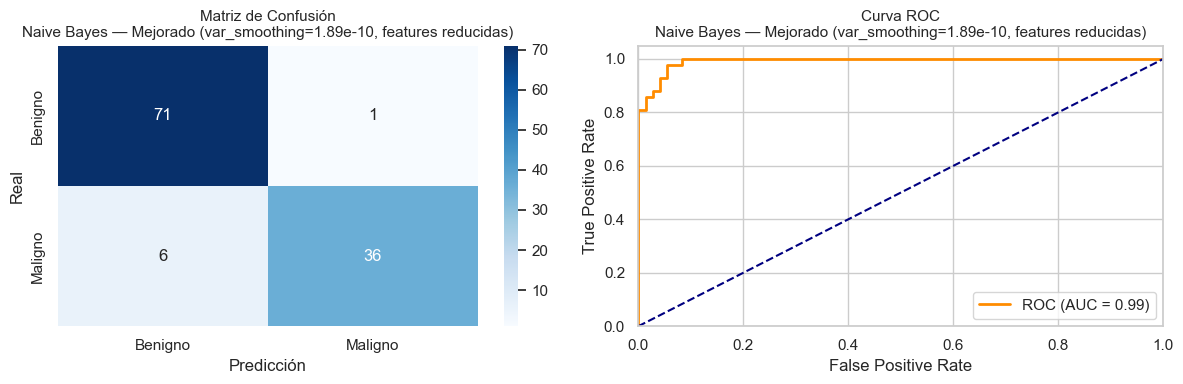

In [67]:
# ── Naive Bayes — Mejorado ────────────────────────────────────────────────────
# Cambios: var_smoothing óptimo + solo features con alta correlación
X_train_nb_red = X_train[features_altas].values
X_test_nb_red  = X_test[features_altas].values

nb_mejor = GaussianNB(var_smoothing=sv_opt)
nb_mejor.fit(X_train_nb_red, y_train)

y_pred_nb_mejor = nb_mejor.predict(X_test_nb_red)
y_prob_nb_mejor = nb_mejor.predict_proba(X_test_nb_red)[:, 1]

res = evaluar_modelo(f'Naive Bayes — Mejorado (var_smoothing={sv_opt:.2e}, features reducidas)',
                     y_test, y_pred_nb_mejor, y_prob_nb_mejor)
resultados.append(res)

---
# **Sección 5: Comparación Final de Modelos**

Se consolidan los resultados de los 6 modelos entrenados para una comparación directa  
y se identifica el mejor modelo según las métricas más relevantes para el dominio clínico.

In [68]:
# ── Tabla comparativa ──────────────────────────────────────────────────────────
df_res = pd.DataFrame(resultados)
df_res = df_res.set_index('modelo')
df_res = df_res.round(4)

print('\n' + '='*80)
print('       TABLA COMPARATIVA DE MODELOS')
print('='*80)
print(df_res.to_string())
print('='*80)

df_res


       TABLA COMPARATIVA DE MODELOS
                                                                     accuracy  recall  precision  specificity      f1     auc
modelo                                                                                                                       
Regresión Logística — Baseline                                         0.9649  0.9286     0.9750       0.9861  0.9512  0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.9474  0.8810     0.9737       0.9861  0.9250  0.9977
K-NN — Baseline (K=3, uniforme)                                        0.9561  0.9048     0.9744       0.9861  0.9383  0.9846
K-NN — Mejorado (K=7, distance, sin atípicos)                          0.9649  0.9286     0.9750       0.9861  0.9512  0.9960
Naive Bayes — Baseline (var_smoothing=1e-9)                            0.9386  0.8333     1.0000       1.0000  0.9091  0.9934
Naive Bayes — Mejorado (var_smoothing=1.89e-10, features reducidas)    0.9386  0.

,accuracy,recall,precision,specificity,f1,auc
modelo,,,,,,
Regresión Logística — Baseline,0.9649,0.9286,0.9750,0.9861,0.9512,0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1),0.9474,0.8810,0.9737,0.9861,0.9250,0.9977
"K-NN — Baseline (K=3, uniforme)",0.9561,0.9048,0.9744,0.9861,0.9383,0.9846
"K-NN — Mejorado (K=7, distance, sin atípicos)",0.9649,0.9286,0.9750,0.9861,0.9512,0.9960
Naive Bayes — Baseline (var_smoothing=1e-9),0.9386,0.8333,1.0000,1.0000,0.9091,0.9934
"Naive Bayes — Mejorado (var_smoothing=1.89e-10, features reducidas)",0.9386,0.8571,0.9730,0.9861,0.9114,0.9921


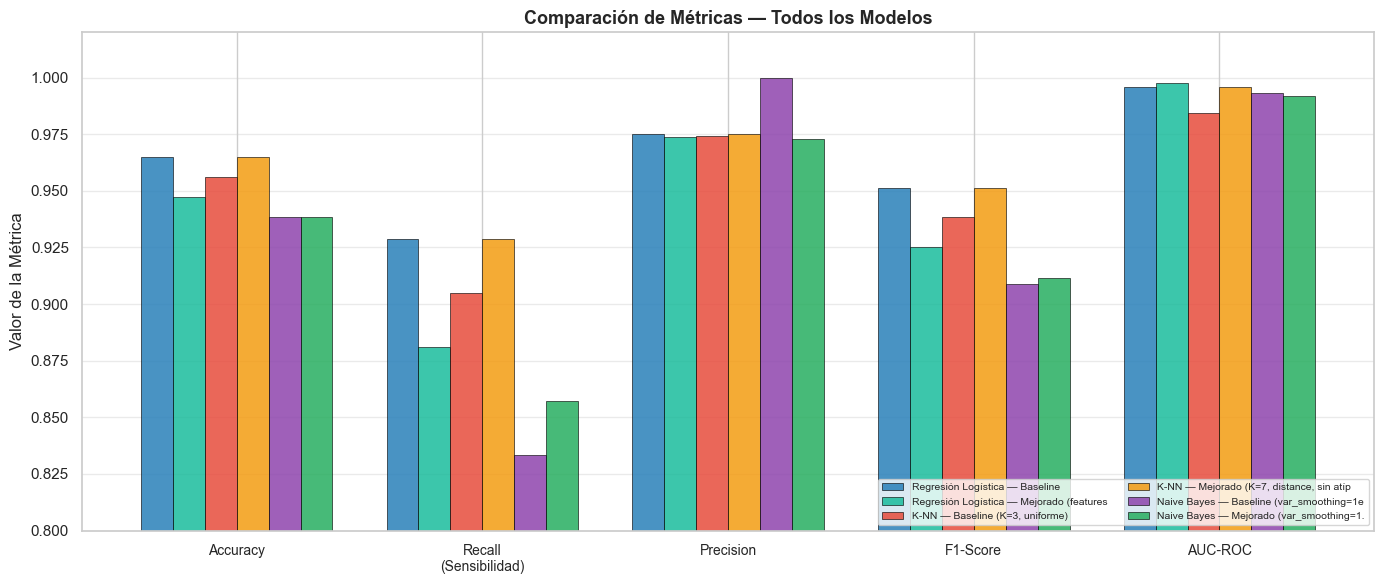

In [69]:
# ── Gráfico radar / barras comparativo ────────────────────────────────────────
metricas = ['accuracy', 'recall', 'precision', 'f1', 'auc']
x        = np.arange(len(metricas))
ancho    = 0.13
colores  = ['#2980b9', '#1abc9c', '#e74c3c', '#f39c12', '#8e44ad', '#27ae60']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (idx, row) in enumerate(df_res.iterrows()):
    ax.bar(x + i*ancho, row[metricas].values, ancho,
           label=idx[:40], color=colores[i], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + ancho * 2.5)
ax.set_xticklabels(['Accuracy', 'Recall\n(Sensibilidad)', 'Precision',
                     'F1-Score', 'AUC-ROC'], fontsize=10)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas — Todos los Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5, ncol=2)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

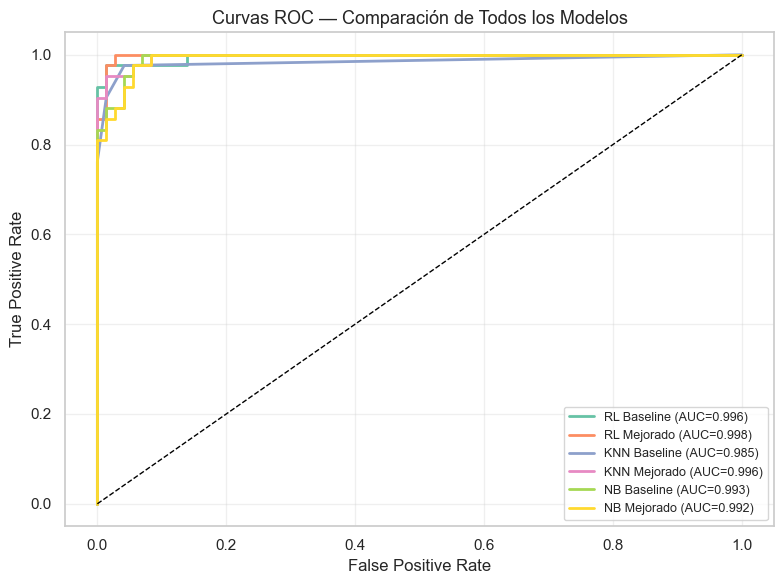

In [70]:
# ── Curvas ROC superpuestas ───────────────────────────────────────────────────
modelos_roc = [
    ('RL Baseline',  y_prob_rl_base),
    ('RL Mejorado',  y_prob_rl_mejor),
    ('KNN Baseline', y_prob_knn_base),
    ('KNN Mejorado', y_prob_knn_mejor),
    ('NB Baseline',  y_prob_nb_base),
    ('NB Mejorado',  y_prob_nb_mejor),
]

plt.figure(figsize=(8, 6))
for nombre, probs in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC={auc_val:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curvas ROC — Comparación de Todos los Modelos', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()